# Predictive Coding: Supervised Learning

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import torch.nn.functional as F
import random
import numpy as np
import os
import matplotlib.pyplot as plt
import copy 
from tqdm import tqdm

# load predictive coding library
import predictive_coding as pc

# 1. Load the MNIST dataset

In [2]:
n_train = 10000
n_val = 500
n_test = 5000
batch_size = 500

# get mnist data
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: torch.flatten(x))])
dataset_train = datasets.MNIST('./data', download=True, train=True, transform=transform)
dataset_eval = datasets.MNIST('./data', download=True, train=False, transform=transform)

# we use only 10.000 data points!
train_dataset = torch.utils.data.Subset(dataset_train, random.sample(range(len(dataset_train)), n_train))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Randomly sample the val dataset
val_dataset, test_dataset, not_used = torch.utils.data.random_split(dataset_eval, [n_val, n_test, dataset_eval.__len__()-n_val-n_test])

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:02<00:00, 3.99MB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 278kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:03<00:00, 456kB/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 2.82MB/s]

10000
500
5000


In [3]:
input_size = 10        # for the 10 classes
hidden_size = 256
hidden2_size = 256
output_size = 28*28    # for the 28 by 28 mnist images

pc_model = nn.Sequential(
      nn.Linear(input_size, hidden_size),
      pc.PCLayer(),         # contains neural activity of layer 2                  
      nn.ReLU(),
      nn.Linear(hidden_size, hidden2_size),
      pc.PCLayer(),         # contains neural activity of layer 1
      nn.ReLU(),
      nn.Linear(hidden2_size, output_size)
  )

pc_model.train()

Sequential(
  (0): Linear(in_features=10, out_features=256, bias=True)
  (1): PCLayer()
  (2): ReLU()
  (3): Linear(in_features=256, out_features=256, bias=True)
  (4): PCLayer()
  (5): ReLU()
  (6): Linear(in_features=256, out_features=784, bias=True)
)

In [4]:
device = "mps"
pc_model.to(device)

Sequential(
  (0): Linear(in_features=10, out_features=256, bias=True)
  (1): PCLayer()
  (2): ReLU()
  (3): Linear(in_features=256, out_features=256, bias=True)
  (4): PCLayer()
  (5): ReLU()
  (6): Linear(in_features=256, out_features=784, bias=True)
)

In [5]:
# number of neural activity updates
# T = 20                              
# optimizer for activity updates
optimizer_x_fn = optim.Adam         
optimizer_x_kwargs = {'lr': 0.1}    
# optimizer for weight updates
optimizer_p_fn = optim.Adam          
optimizer_p_kwargs = {"lr": 0.001, "weight_decay":0.001} 

trainer = pc.PCTrainer(pc_model, 
    T = 20, 
    optimizer_x_fn = optimizer_x_fn,               # optimizer for activity updates
    optimizer_x_kwargs = optimizer_x_kwargs,
    optimizer_p_fn = optimizer_p_fn,           # optimizer for weight updates
    optimizer_p_kwargs = optimizer_p_kwargs
)

In [6]:
def loss_fn(output, _target):
    return 0.5*(output - _target).pow(2).sum()

# This class contains the parameters of the prior mean \mu parameter (see figure)
class BiasLayer(nn.Module):
    def __init__(self, out_features, offset=0.):
        super(BiasLayer, self).__init__()
        self.bias = nn.Parameter(offset*torch.ones(out_features) if offset is not None else 2*np.sqrt(out_features)*torch.rand(out_features)-np.sqrt(out_features), requires_grad=True)

    def forward(self, x):
        return torch.zeros_like(x) + self.bias  # return the prior mean \mu witht the same shape as the input x to make sure the batch size is the same


def test_normal(model, dataset, batch_size=1000):
    test_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # add bias layer for inferece
    test_model = nn.Sequential(
        BiasLayer(10, offset=0.),
        pc.PCLayer(),
        model
    )
    test_model.train()
    test_model.to(device)

    # make pc_trainer for test_model
    trainer_normal_test = pc.PCTrainer(test_model,
        T = 100,
        update_x_at = "all",
        optimizer_x_fn = optimizer_x_fn,
        optimizer_x_kwargs = optimizer_x_kwargs,
        update_p_at = "never",
        optimizer_p_fn = optimizer_p_fn,
        optimizer_p_kwargs = optimizer_p_kwargs,
        plot_progress_at=[]
    )

    correct_count, all_count = 0., 0.
    for data, labels in (test_loader):
        pseudo_input = torch.zeros(data.shape[0], 10)
        data, labels, pseudo_input = data.to(device), labels.to(device), pseudo_input.to(device)

        # MAP inference
        trainer_normal_test.train_on_batch(inputs=pseudo_input, loss_fn=loss_fn, loss_fn_kwargs={'_target':data}, is_log_progress=False, is_return_results_every_t=False, is_checking_after_callback_after_t=False)
        pred = torch.max(test_model[1].get_x(), dim=1)
        correct = (pred.indices == labels).long()
        correct_count += correct.sum()
        all_count += correct.size(0)
    return round((correct_count / all_count).item(), 4)

In [7]:
epochs = 10
batch_size = 500

best_val_acc = 0
best_model = copy.deepcopy(pc_model.state_dict())
best_model_idx = None

train_acc = [test_normal(pc_model, test_dataset)]
val_acc = [test_normal(pc_model, val_dataset)]
for epoch in range(epochs):
    for data, label in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        data, label = data.to(device), label.to(device)
        # labels to one-hot
        labels_one_hot = F.one_hot(label).float()
        trainer.train_on_batch(inputs=labels_one_hot, 
                               loss_fn=loss_fn, 
                               loss_fn_kwargs={'_target':data}, 
                               is_log_progress=False, 
                               is_return_results_every_t=False, 
                               is_checking_after_callback_after_t=False)
    val_acc.append(test_normal(pc_model, val_dataset))
    if val_acc[-1] > best_val_acc:
        best_val_acc = val_acc[-1]
        best_model = copy.deepcopy(pc_model.state_dict())
        best_model_idx = epoch
    print(f'Epoch {epoch+1} - Val acc: {val_acc[-1]}')




Epoch 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 22.59it/s]


Epoch 1 - Val acc: 0.684


Epoch 2: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 23.78it/s]


Epoch 2 - Val acc: 0.822


Epoch 3: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 23.79it/s]


...

Epoch 8 - Val acc: 0.852


Epoch 9: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 21.04it/s]


Epoch 9 - Val acc: 0.846


Epoch 10: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 23.88it/s]


Epoch 10 - Val acc: 0.844


Test accuracy: 0.855


Text(0.5, 1.0, 'Normal PC with test accuracy: 0.855')

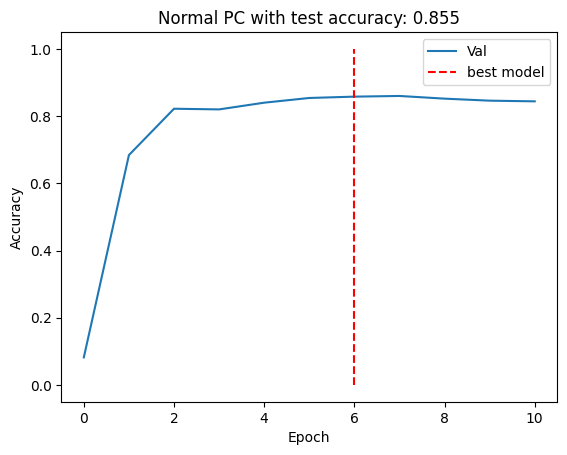

In [8]:
test_model = pc_model
test_model.train()
test_model.load_state_dict(best_model, strict=False)
test_model.to(device)
acc_test = test_normal(test_model, test_dataset)
print(f'Test accuracy: {acc_test}')


plt.plot(val_acc, label='Val')
plt.vlines(best_model_idx, 0, 1, colors="r", linestyles="dashed", label="best model")
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f'Normal PC with test accuracy: {acc_test}')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 396.40it/s]


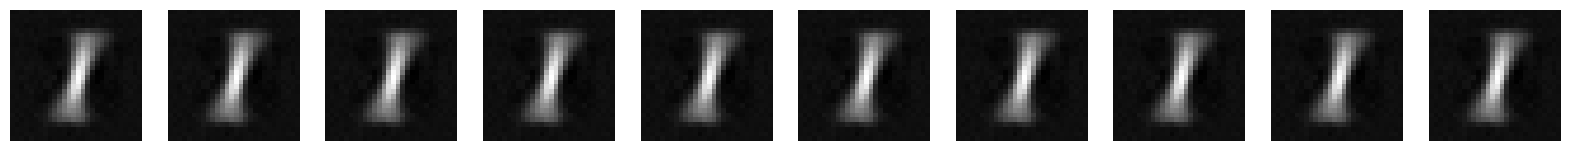

In [10]:
test_model.eval() # this changes the code to perform a forward pass insteady of minimising prediction errors

imgs = []
for i in tqdm(range(10)):
    input = torch.zeros(1, 10)
    input[0, i] = 1
    input = input.to(device)

    img = test_model(input)
    imgs.append(img.cpu().detach().numpy().reshape(28, 28))

# show 10 images one for each digit
fig, ax = plt.subplots(1, 10, figsize=(20, 2))
for i in range(10):
    ax[i].imshow(imgs[i], cmap='gray')
    ax[i].axis('off')